**Table of contents**<a id='toc0_'></a>    
- [Photoswitching fingerprints of 1 fluorophore](#toc1_)    
  - [CDF Fitting procedure](#toc1_1_)    
  - [Reading and fitting data](#toc1_2_)    
    - [Bleaching rate data](#toc1_2_1_)    
    - [ON to OFF data](#toc1_2_2_)    
    - [OFF to ON data](#toc1_2_3_)    
  - [Figure](#toc1_3_)    
    - [Preparation](#toc1_3_1_)    
    - [Figure](#toc1_3_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswitching fingerprints of 1 fluorophore](#toc0_)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes
from lmfit import Model, Parameters
from matplotlib import rcParams
from matplotlib.lines import Line2D

import fluopy.blinking as bl
import fluopy.distributions as dist
import fluopy.emissions as em
import fluopy.figure as fi
import fluopy.miscellaneous as mi

%load_ext autoreload
%autoreload 2

reading_from = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_3_single_f_PFA"

## <a id='toc1_1_'></a>[CDF Fitting procedure](#toc0_)

In [2]:
# note: this is not the same fitting procedure as done for the 2F, 3F, 4F data
# however, the same model is used
# here, the number of not observed events is not included, and the eCDF is fitted
# for the 2F, 3F and 4F data, the log-likelihood of bins is maximized and it includes
# the number of not observed events
def target_cdf(x, p, lambda1, lambda2):
    mixture = dist.ExponentialMixtureModel(
        params={"pis": [p], "lambdas": [lambda1, lambda2]}, domain=(0, 300)
    )
    return mixture.cdf(x)


def fit_two_expon_mixture(data):
    x = np.linspace(0, 300, 300001)
    model = Model(target_cdf)
    params = Parameters()
    params.add("p", value=0.5, min=0, max=1)
    params.add("lambda1", value=1, min=0)
    params.add("lambda2", value=0.5, min=0)
    result = model.fit(data, params, x=x)
    parameters = [param.value for param in result.params.values()]

    return parameters

## <a id='toc1_2_'></a>[Reading and fitting data](#toc0_)

### <a id='toc1_2_1_'></a>[Bleaching rate data](#toc0_)

In [3]:
identifiers = ["1e1", "1e2", "1e3", "1e4"]
fingerprints_all_A = []
total_photons_A = []
parameters_all_fit_cdf_A = []
folder_path = reading_from + r"\bl_rate"
for i, id in enumerate(identifiers):
    fingerprints_all_A.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    total_photons_A.append([])
    for file in Path(folder_path + "\\" + id).iterdir():
        if file.suffix == ".parquet":
            fingerprints_all_A[i] += pd.read_parquet(file).sum(axis=1)
            total_photons_A[i] += pd.read_parquet(file).sum(axis=0).values.tolist()
    fingerprint = fingerprints_all_A[i].cumsum() / fingerprints_all_A[i].sum()
    fingerprints_all_A[i] = fingerprint
    parameters_all_fit_cdf_A.append(fit_two_expon_mixture(fingerprint))

### <a id='toc1_2_2_'></a>[ON to OFF data](#toc0_)

In [4]:
identifiers = ["1", "01", "005", "001"]
fingerprints_all_B = []
ON_periods_B_frames = []
parameters_all_fit_cdf_B = []
folder_path = reading_from + r"\off_prob"
emis = em.Emissions()
for i, id in enumerate(identifiers):
    fingerprints_all_B.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    ON_periods_B_frames.append([])
    for file in Path(folder_path + "\\" + id).iterdir():
        if file.suffix == ".parquet":
            data = pd.read_parquet(file)
            fingerprints_all_B[i] += data.sum(axis=1)
            for col in data.columns:
                emis.event_time_series = data[col]
                blinks = bl.Blinking(emis)
                ON_periods_B_frames[i] += blinks.on_periods.tolist()
    fingerprint = fingerprints_all_B[i].cumsum() / fingerprints_all_B[i].sum()
    fingerprints_all_B[i] = fingerprint
    parameters_all_fit_cdf_B.append(fit_two_expon_mixture(fingerprint))

### <a id='toc1_2_3_'></a>[OFF to ON data](#toc0_)

In [5]:
identifiers = ["5e-2", "5e-1", "5e0", "5e1"]
fingerprints_all_C = []
OFF_periods_C_frames = []
parameters_all_fit_cdf_C = []
folder_path = reading_from + r"\off_time"
emis = em.Emissions()
for i, id in enumerate(identifiers):
    fingerprints_all_C.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    OFF_periods_C_frames.append([])
    for file in Path(folder_path + "\\" + id).iterdir():
        if file.suffix == ".parquet":
            data = pd.read_parquet(file)
            fingerprints_all_C[i] += data.sum(axis=1)
            for col in data.columns:
                emis.event_time_series = data[col]
                blinks = bl.Blinking(emis)
                OFF_periods_C_frames[i] += blinks.off_periods.tolist()
    fingerprint = fingerprints_all_C[i].cumsum() / fingerprints_all_C[i].sum()
    fingerprints_all_C[i] = fingerprint
    parameters_all_fit_cdf_C.append(fit_two_expon_mixture(fingerprint))

## <a id='toc1_3_'></a>[Figure](#toc0_)

### <a id='toc1_3_1_'></a>[Preparation](#toc0_)

In [6]:
total_photons_A = [np.array(total_photons) for total_photons in total_photons_A]
minimum = np.min([np.min(a) for a in total_photons_A])
if minimum == 0:
    minimum = 1
maximum = np.max([np.max(a) for a in total_photons_A])
log_bins_A = np.logspace(np.log10(minimum), np.log10(maximum), 50)

# ON periods in seconds
ON_periods_B = [np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_B_frames]

# OFF periods in seconds
OFF_periods_C = [np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_C_frames]
minimum = np.min([np.min(a) for a in OFF_periods_C])
maximum = np.max([np.max(a) for a in OFF_periods_C])
log_bins_C = np.logspace(np.log10(minimum), np.log10(maximum), 50)

weights_B = [np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_B]
weights_C = [
    np.ones_like(OFF_periods) / OFF_periods.size for OFF_periods in OFF_periods_C
]
weights_A = [
    np.ones_like(total_photons) / total_photons.size
    for total_photons in total_photons_A
]

### <a id='toc1_3_2_'></a>[Figure](#toc0_)

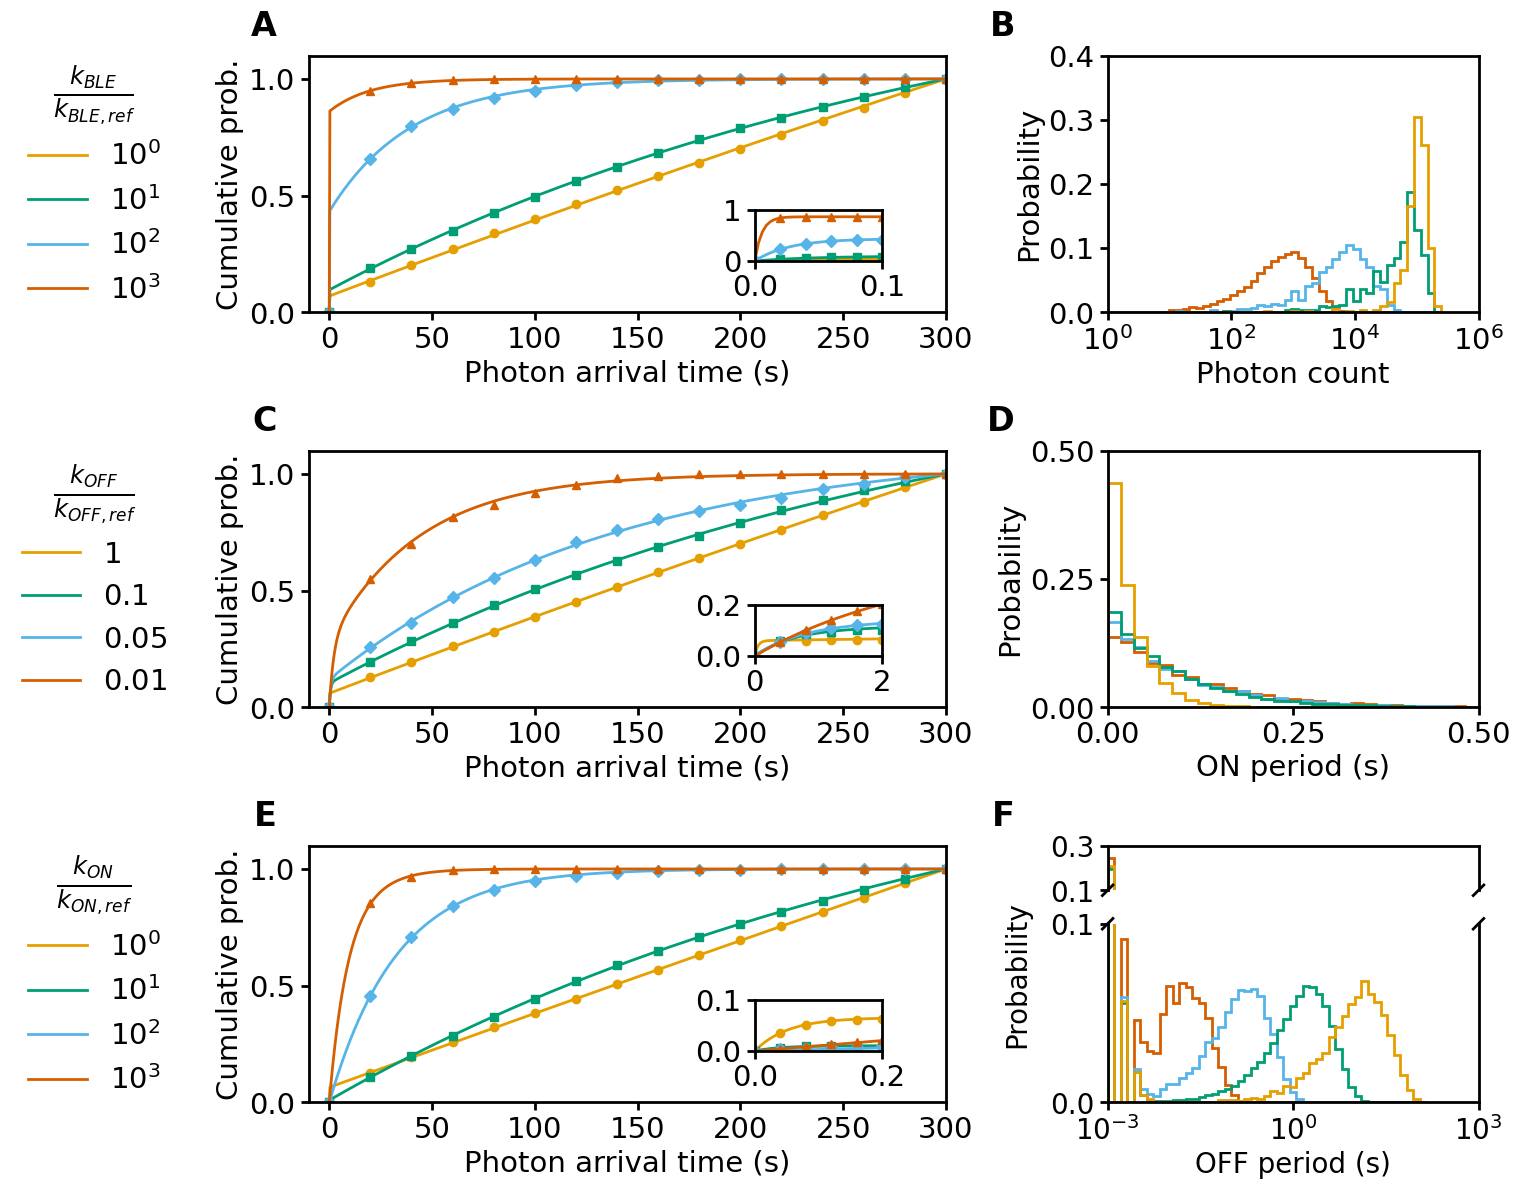

: 

In [ ]:
from matplotlib.transforms import BlendedGenericTransform

red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [orange, green, sky_blue, red]

custom_handles = [
    Line2D([0], [0], color=orange, lw=2),
    Line2D([0], [0], color=green, lw=2),
    Line2D([0], [0], color=sky_blue, lw=2),
    Line2D([0], [0], color=red, lw=2),
]


def plot_figure3(
    ax, labels, data, fit, legendtitle, xlim2, ylim2, spacing2, colors=colors
):
    markers = ["o", "s", "D", "^"]
    x = np.linspace(0, 300, 1000)
    spacing1 = 20000
    description = dict(
        ylabel="Cumulative prob.",
        xlabel="Photon arrival time (s)",
        xlim=[-10, 300],
        ylim=[0, 1.1],
    )
    for fingerprint, parameters, label, color, marker in zip(
        data, fit, labels, colors, markers
    ):
        pi, lambda1, lambda2 = parameters
        fi.universal_figure(
            data=[fingerprint.index[::spacing1], fingerprint[::spacing1]],
            label=label,
            color=color,
            marker=marker,
            linestyle="",
            axes=ax,
        )
        fi.universal_figure(
            data=[
                x,
                dist.ExponentialMixtureModel(
                    params={"pis": [pi], "lambdas": [lambda1, lambda2]}, domain=(0, 300)
                ).cdf(x),
            ],
            color=color,
            lw=2,
            axes=ax,
        )
    fi.universal_figure(
        axes=ax,
        **description,
    )

    inset = ax.inset_axes([0.7, 0.2, 0.2, 0.2], xlim=(0, xlim2), ylim=(0, ylim2))
    x = np.linspace(0, 300, 100000)
    for fingerprint, parameters, label, color, marker in zip(
        data, fit, labels, colors, markers
    ):
        pi, lambda1, lambda2 = parameters
        fi.universal_figure(
            data=[fingerprint.index[::spacing2], fingerprint[::spacing2]],
            axes=inset,
            label=label,
            color=color,
            marker=marker,
            linestyle="",
        )
        fi.universal_figure(
            data=[
                x,
                dist.ExponentialMixtureModel(
                    params={"pis": [pi], "lambdas": [lambda1, lambda2]}, domain=(0, 300)
                ).cdf(x),
            ],
            axes=inset,
            lw=2,
            color=color,
        )
    inset.set_ylabel("")
    inset.set_xlabel("")


rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 6)
fig = plt.figure(figsize=(15, 12))
ax12 = fig.add_subplot(gs[0, 0])

ax1 = fig.add_subplot(gs[0, 1:4])
labels1 = [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"]
legendtitle1 = r"$\frac{k_{BLE}}{k_{BLE,ref}}$"
plot_figure3(
    ax1, labels1, fingerprints_all_A, parameters_all_fit_cdf_A, legendtitle1, 0.1, 1, 20
)

ax2 = fig.add_subplot(gs[0, 4:])
fi.universal_figure(
    type_="hist",
    data=total_photons_A,
    axes=ax2,
    density=False,
    histtype="step",
    label=labels1,
    color=colors,
    alpha=1,
    weights=weights_A,
    xscale="log",
    bins=log_bins_A,
    ylim=[0, 0.4],
    xlim=[1e0, 1e6],
    ylabel="Probability",
    xlabel="Photon count",
    lw=2,
)


ax12.axis("off")
ax12.legend(
    custom_handles,
    labels1,
    loc="center",
    frameon=False,
    fontsize=21,
    title=legendtitle1,
    title_fontsize=25,
)

ax34 = fig.add_subplot(gs[1, 0])

ax3 = fig.add_subplot(gs[1, 1:4])
labels3 = [r"$1$", r"$0.1$", r"$0.05$", r"$0.01$"]
legendtitle3 = r"$\frac{k_{OFF}}{k_{OFF,ref}}$"
plot_figure3(
    ax3,
    labels3,
    fingerprints_all_B,
    parameters_all_fit_cdf_B,
    legendtitle3,
    2,
    0.2,
    400,
)
ax4 = fig.add_subplot(gs[1, 4:])
fi.universal_figure(
    type_="hist",
    data=ON_periods_B,
    axes=ax4,
    density=False,
    label=labels3,
    color=colors,
    alpha=1,
    weights=weights_B,
    ylabel="Probability",
    xlabel="ON period (s)",
    histtype="step",
    bins=60,
    lw=2,
    ylim=[0, 0.5],
    xlim=[0, 0.5],
    xticks=[0, 0.25, 0.5],
    yticks=[0, 0.25, 0.5],
)

ax34.axis("off")
ax34.legend(
    custom_handles,
    labels3,
    loc="center",
    frameon=False,
    fontsize=21,
    title=legendtitle3,
    title_fontsize=25,
)
ax56 = fig.add_subplot(gs[2, 0])

ax5 = fig.add_subplot(gs[2, 1:4])
labels5 = [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"]
legendtitle5 = r"$\frac{k_{ON}}{k_{ON,ref}}$"
plot_figure3(
    ax5,
    labels5,
    fingerprints_all_C,
    parameters_all_fit_cdf_C,
    legendtitle5,
    0.2,
    0.1,
    40,
)
bax6 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.3)),
    subplot_spec=gs[2, 4:],
    despine=False,
    d=0.005,
    hspace=0.3,
    height_ratios=(1, 4),
)
bax6.hist(
    OFF_periods_C,
    density=False,
    histtype="step",
    lw=2,
    label=labels5,
    color=colors,
    alpha=1,
    bins=log_bins_C,
    weights=weights_C,
)
bax6.set_xscale("log")
bax6.set_ylabel("Probability", fontsize=20, labelpad=55)
bax6.set_xlabel("OFF period (s)", fontsize=20, labelpad=35)
bax6.tick_params(labelsize=20, width=2, length=6)
bax6.set_xlim([1e-3, 1e3])
bax6.set_xticks([1e-3, 1e0, 1e3])
bax6.axs[0].set_yticks([0.1, 0.3])
bax6.axs[1].set_yticks([0, 0.1])


ax56.axis("off")
ax56.legend(
    custom_handles,
    labels5,
    loc="center",
    frameon=False,
    fontsize=21,
    title=legendtitle5,
    title_fontsize=25,
)
axes = fig.get_axes()
letters = ["A", "B", "C", "D", "E"]
j = 0
for i, axis in enumerate(axes):
    if j >= len(letters):
        break
    if i % 3 == 0:
        continue
    elif i % 3 == 1:
        offset = -0.05
    else:
        offset = -0.25
    axis.text(
        offset,
        1.05,
        letters[j],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
    j += 1

mix_transform = BlendedGenericTransform(axes[8].transAxes, axes[10].transAxes)
axes[8].text(
    -0.25,
    1.05,
    "F",
    transform=mix_transform,
    fontsize=24,
    fontweight="bold",
    va="bottom",
    ha="right",
)

fig.tight_layout()

for handle in bax6.diag_handles:
    handle.remove()
bax6.draw_diags()

bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
fig.savefig(
    reading_from + r"\single_f_PFA.png",
    dpi=300,
    bbox_inches=bbox,
)